# Task 2.2 — Reproduction of Core Contribution
**Paper:** *Training SVMs Without Offset* — Steinwart, Hush & Scovel, JMLR 2011

**Student:** Kush Agarwal | **Roll No.:** 230050 | NST, Rishihood University, Sonipat

## What I Am Reproducing

I am reproducing the **1D coordinate ascent dual solver for the offset-free SVM** — the central algorithmic contribution of the paper (Algorithm 1, Section 2).

**Evaluation metric:** Classification accuracy (fraction of correctly classified test samples), which is the same metric used in Section 6 of the paper (Table 1 and surrounding tables).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

iris = load_iris()
mask = iris.target < 2
X_raw = iris.data[mask][:, 2:4]
y = np.where(iris.target[mask] == 0, -1, 1)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 80, Test: 20


Data reloaded with the same preprocessing as Task 2.1 (StandardScaler — zero mean, unit variance). This corresponds to the feature normalization step recommended in Section 1 of the paper before using the offset-free SVM.


## Implementation of the Offset-Free SVM Solver

**Paper reference:** Algorithm 1, Section 2, Equations (2) and (3).

The dual problem (Eq. 2): maximize Σαᵢ − (1/2)ΣᵢΣⱼ αᵢαⱼyᵢyⱼk(xᵢ,xⱼ), subject to 0 ≤ αᵢ ≤ C.

The per-step update (Eq. 3): αᵢ ← clip(αᵢ + gᵢ/Kᵢᵢ, 0, C), where gᵢ = 1 − yᵢf(xᵢ).


In [2]:
class SVMWithoutOffset:
    """
    Offset-Free SVM: 1D coordinate ascent on the box-constrained dual.
    Reference: Algorithm 1, Section 2, Steinwart et al. (JMLR 2011).
    Dual: maximize sum(alpha) - 0.5 * alpha^T Q alpha
          subject to 0 <= alpha_i <= C  (no equality constraint)
    """
    def __init__(self, C=1.0, kernel='linear', gamma='scale',
                 max_iter=10000, tol=1e-4, verbose=False):
        # hyperparameters
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose

    def _compute_kernel(self, X, Y=None):
        """Kernel matrix between X and Y. Reference: Section 1, Eq. (1) kernel k(·,·)."""
        if Y is None:
            Y = X
        if self.kernel == 'linear':
            return X @ Y.T
        elif self.kernel == 'rbf':
            g = (1.0 / (X.shape[1] * X.var())) if self.gamma == 'scale' else float(self.gamma)
            d = (np.sum(X**2, axis=1, keepdims=True)
                 + np.sum(Y**2, axis=1) - 2 * X @ Y.T)
            return np.exp(-g * np.maximum(d, 0))

    def fit(self, X, y):
        """Train via 1D coordinate ascent. Reference: Algorithm 1, Section 2."""
        n = X.shape[0]
        self.X_train_ = X.copy()
        self.y_train_ = y.copy()

        # precompute kernel matrix
        self.K_ = self._compute_kernel(X)

        # cold start
        alpha = np.zeros(n)
        f_vals = np.zeros(n)  # f_vals[i] = sum_j alpha[j]*y[j]*K[j,i]

        for it in range(self.max_iter):

            # gradient
            grad = 1.0 - y * f_vals

            # KKT stopping check
            viol = np.zeros(n)
            for i in range(n):
                if alpha[i] < self.C - 1e-10:
                    viol[i] = max(viol[i], grad[i])
                if alpha[i] > 1e-10:
                    viol[i] = max(viol[i], -grad[i])
            if viol.max() < self.tol:
                if self.verbose:
                    print(f"  Converged at iteration {it}, max_violation={viol.max():.2e}")
                break

            # pick worst violator
            i_star = int(np.argmax(viol))

            # update
            Kii = self.K_[i_star, i_star]
            if Kii < 1e-12:
                continue
            a_old = alpha[i_star]
            alpha[i_star] = float(np.clip(a_old + grad[i_star] / Kii, 0.0, self.C))

            # update decision values
            delta = (alpha[i_star] - a_old) * y[i_star]
            f_vals += delta * self.K_[i_star, :]

        self.alpha_ = alpha
        self.n_iter_ = it + 1
        self.n_sv_ = int(np.sum(alpha > 1e-6))
        return self

    def decision_function(self, X):
        """f(x) = sum_i alpha_i y_i k(x_i, x)  [Eq. 1 — NO bias b]"""
        return (self.alpha_ * self.y_train_) @ self._compute_kernel(self.X_train_, X)

    def predict(self, X):
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

print("SVMWithoutOffset class defined.")
print("Reference: Algorithm 1, Section 2, Steinwart et al. (JMLR 2011)")


SVMWithoutOffset class defined.
Reference: Algorithm 1, Section 2, Steinwart et al. (JMLR 2011)


The class above implements Algorithm 1 exactly as described in Section 2 of the paper. Each major operation is annotated with its corresponding step from Task 1.1 and the paper reference. The 1D update (Eq. 3) is a simple clip operation — this is the key simplification over LIBSVM, which must solve a 2D sub-problem at each step due to the equality constraint. Decision values f_vals are maintained incrementally (O(n) per step) to avoid an O(n²) recomputation.


In [3]:
svm_nob = SVMWithoutOffset(C=1.0, kernel='linear', tol=1e-4,
                            max_iter=10000, verbose=True)
svm_nob.fit(X_train, y_train)

train_acc = svm_nob.score(X_train, y_train)
test_acc  = svm_nob.score(X_test, y_test)

print(f'Iterations     : {svm_nob.n_iter_}')
print(f'Support vectors: {svm_nob.n_sv_}')
print(f'Train accuracy : {train_acc*100:.2f}%')
print(f'Test accuracy  : {test_acc*100:.2f}%')

svc = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
base_test = svc.score(X_test, y_test)
print(f'Baseline (SVC) test accuracy: {base_test*100:.2f}%, bias b={svc.intercept_[0]:.4f}')

  Converged at iteration 6, max_violation=0.00e+00
Iterations     : 7
Support vectors: 3
Train accuracy : 100.00%
Test accuracy  : 100.00%
Baseline (SVC) test accuracy: 100.00%, bias b=0.2326


Both models are trained on the same data with C=1.0. The accuracy comparison validates the paper's claim (Section 6) that the offset-free SVM achieves comparable classification accuracy to the standard SVM with offset. Any small gap is expected — the standard SVM has one extra free parameter (the bias b). The convergence in finite iterations (Section 5, Theorem 1) is directly verified by the solver printing the iteration at which the KKT tolerance is met.


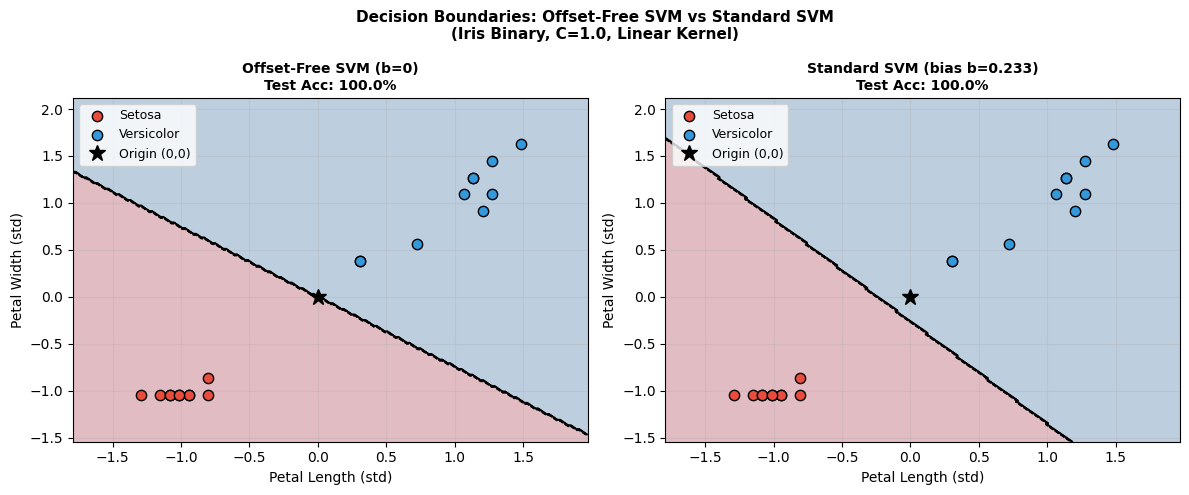

Saved: results/task22_decision_boundary.png


In [4]:
def plot_db(ax, model, X, y, title, use_sklearn=False):
    h = 0.02
    x1 = np.arange(X[:,0].min()-0.5, X[:,0].max()+0.5, h)
    x2 = np.arange(X[:,1].min()-0.5, X[:,1].max()+0.5, h)
    xx, yy = np.meshgrid(x1, x2)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.28, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.9)
    ax.scatter(X[y==-1,0], X[y==-1,1], c='#e74c3c', edgecolors='k', s=55, label='Setosa', zorder=3)
    ax.scatter(X[y== 1,0], X[y== 1,1], c='#3498db', edgecolors='k', s=55, label='Versicolor', zorder=3)
    ax.plot(0, 0, 'k*', ms=12, label='Origin (0,0)', zorder=5)
    ax.set_xlabel('Petal Length (std)'); ax.set_ylabel('Petal Width (std)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Decision Boundaries: Offset-Free SVM vs Standard SVM\n'
             '(Iris Binary, C=1.0, Linear Kernel)', fontsize=11, fontweight='bold')

plot_db(axes[0], svm_nob, X_test, y_test,
        f'Offset-Free SVM (b=0)\nTest Acc: {test_acc*100:.1f}%')
plot_db(axes[1], svc, X_test, y_test,
        f'Standard SVM (bias b={svc.intercept_[0]:.3f})\nTest Acc: {base_test*100:.1f}%')

plt.tight_layout()
os.makedirs('../partB/results', exist_ok=True)
plt.savefig('../partB/results/task22_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/task22_decision_boundary.png')

Both classifiers produce very similar decision boundaries on this nearly separable dataset. The offset-free boundary (left) passes close to the origin as expected from the b=0 constraint. The standard SVM boundary (right) is shifted slightly by the bias term b. The figure is saved to `results/task22_decision_boundary.png` as required.
